# IMDb Sentiment Analysis with Transformer Models



This project explores binary sentiment classification of movie reviews using transformer-based models.

Models evaluated:

- BERT
- RoBERTa
- DistilBERT

Dataset:

- IMDb movie reviews (50,000 labeled samples)

Goal:

- classify reviews as positive or negative
- compare transformer architectures
- improve validation accuracy through experimentation

In [1]:
import numpy as np
import torch
import pandas as pd

from datasets import load_dataset, Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)



## Hardware Check

Training transformer models requires GPU acceleration.

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")

else:
    device = torch.device("cpu")
    print("Using CPU")

Using Apple Silicon GPU (MPS)


## Load Dataset

We use the IMDb sentiment classification dataset from Hugging Face.

In [3]:
dataset = load_dataset("imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


The dataset contains:

- train: labeled reviews
- test: labeled reviews
- unsupervised: unlabeled reviews

For this project, we only use the labeled training split.

## Train / Validation Split

In [4]:
train_df = dataset["train"].to_pandas()
train_part, valid_part = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=train_df["label"]
)

print("Full training dataset:", train_df.shape)
print("Training split:", train_part.shape)
print("Validation split:", valid_part.shape)

Full training dataset: (25000, 2)
Training split: (20000, 2)
Validation split: (5000, 2)


### Observation

The original training split contains 25,000 labeled reviews.

After splitting:

- Training set: 20,000 reviews
- Validation set: 5,000 reviews

Stratified sampling preserves class balance across both splits.

## EDA

In [5]:
# Class balance
train_part["label"].value_counts()

label
1    10000
0    10000
Name: count, dtype: int64

The dataset is perfectly balanced:

- Negative reviews: 10,000
- Positive reviews: 10,000

This reduces the risk of class imbalance during training.

In [6]:
# Sample reviews
train_part[["text", "label"]].reset_index(drop=True).head(3)

,text,label
0,I have always been a huge James Bond fanatic! ...,1
1,I am a Christian and I say this movie had terr...,0
2,"Neatly sandwiched between THE STRANGER, a smal...",1


In [7]:
train_part[
    train_part["text"].str.contains("<br", regex=False)
].reset_index(drop=True).head(3)

,text,label
0,I am a Christian and I say this movie had terr...,0
1,"Neatly sandwiched between THE STRANGER, a smal...",1
2,"Here's a gritty, get-the-bad guys revenge stor...",1


In [8]:
html_count = train_part["text"].str.contains("<br", regex=False).sum()
print(f"Reviews containing HTML tags: {html_count}")

Reviews containing HTML tags: 11683


Some reviews contain HTML tags such as `<br />`.

These artifacts should be removed during text preprocessing.

In [9]:
# Review lengths
train_part["review_length"] = train_part["text"].apply(len)
train_part["review_length"].describe()

count    20000.00000
mean      1321.28750
std       1000.68021
min         52.00000
25%        701.00000
50%        980.00000
75%       1606.00000
max      13704.00000
Name: review_length, dtype: float64

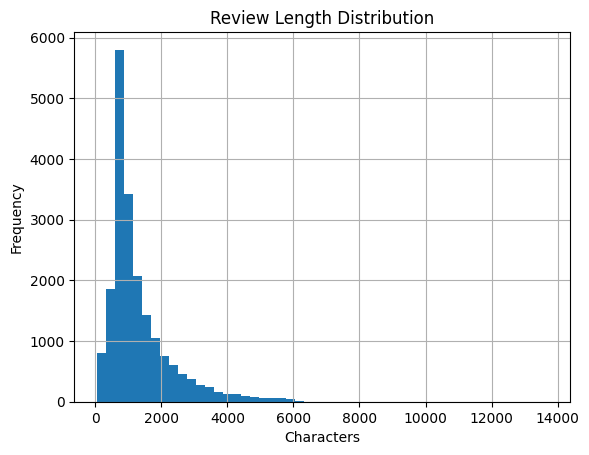

In [10]:
import matplotlib.pyplot as plt

train_part["review_length"].hist(bins=50)

plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

Review lengths are highly right-skewed:

- Mean length: ~1321 characters
- Median length: ~980 characters
- Longest review: 13,704 characters

Most reviews fall between 500–2000 characters, while a small number of reviews are significantly longer.

This distribution suggests that fixed-length tokenization with truncation will be necessary during model training.

### Key Observations

- Dataset is perfectly balanced across classes.
- Average review length is approximately 1321 characters.
- Median review length is approximately 980 characters.
- Some reviews contain HTML artifacts such as `<br />`.
- Text cleaning and tokenization will be applied in the next stage.